# Data Overview and Quality Control

The dataset consists of 160 Langevin dynamics trajectories of a single
nanoparticle (NP) diffusing through a polymer network modelled as a
viscoelastic continuum. Five polymer volume fractions
(phi = 0.00, 0.05, 0.15, 0.30, 0.50) and four NP charge values
(Z = 0, 1, 3, 6 e) are combined with 8 independent runs per condition,
giving 20 distinct physical conditions. Each trajectory spans 15,000
saved frames at a time interval of 0.02 LJ time units. This notebook
checks data integrity and gives a visual overview before any quantitative
analysis.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
DATA_DIR = os.path.abspath('../data')
FIG_DIR  = os.path.abspath('../figures')
os.makedirs(FIG_DIR, exist_ok=True)


In [2]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 11,
    'axes.labelsize'   : 12,
    'axes.titlesize'   : 12,
    'legend.fontsize'  : 10,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.linewidth'   : 0.8,
    'grid.alpha'       : 0.3,
    'grid.linewidth'   : 0.5,
})

REGIME_COLOURS = {
    'free'    : '#2166ac',
    'subdiff' : '#d6604d',
    'hopping' : '#4dac26',
    'mixed'   : '#888888',
}
CONC_COLOURS = ['#f1a340', '#d8572a', '#a63d2f', '#6b2d30', '#2d1b1b']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.io_utils import load_all_trajectories, DATA_DIR

trajs, meta = load_all_trajectories(DATA_DIR)

# Check trajectory counts per condition
grouped = meta.groupby(['polymer_conc', 'np_charge']).size().reset_index(name='n_runs')
print(grouped.to_string(index=False))

# Assert every condition has exactly 8 runs
assert (grouped['n_runs'] == 8).all(), "Some conditions do not have exactly 8 runs."
print("\nAll conditions have exactly 8 runs. Data integrity check passed.")


Loading trajectories: 100%|█████████████████| 160/160 [00:01<00:00, 99.61file/s]

Loaded 160 trajectories across 20 conditions.
 polymer_conc  np_charge  n_runs
         0.00        0.0       8
         0.00        1.0       8
         0.00        3.0       8
         0.00        6.0       8
         0.05        0.0       8
         0.05        1.0       8
         0.05        3.0       8
         0.05        6.0       8
         0.15        0.0       8
         0.15        1.0       8
         0.15        3.0       8
         0.15        6.0       8
         0.30        0.0       8
         0.30        1.0       8
         0.30        3.0       8
         0.30        6.0       8
         0.50        0.0       8
         0.50        1.0       8
         0.50        3.0       8
         0.50        6.0       8

All conditions have exactly 8 runs. Data integrity check passed.


In [4]:
# Representative quality check: one trajectory per condition (20 conditions)
concs   = sorted(meta['polymer_conc'].unique())
charges = sorted(meta['np_charge'].unique())

summary_rows = []
for conc in concs:
    for charge in charges:
        key = (conc, charge, 0)  # run 0 as representative
        if key not in trajs:
            continue
        df = trajs[key]
        disp = df['displacement'].dropna()
        has_nan = df[['x', 'y', 'z']].isna().any().any()
        summary_rows.append({
            'conc'      : conc,
            'charge'    : charge,
            'n_frames'  : len(df),
            'mean_disp' : disp.mean(),
            'max_disp'  : disp.max(),
            'has_nan'   : has_nan,
        })
        print(f"phi={conc:.2f}, Z={charge:.1f}: "
              f"n={len(df)}, mean_disp={disp.mean():.4f}, "
              f"max_disp={disp.max():.4f}, NaN={has_nan}")


phi=0.00, Z=0.0: n=15000, mean_disp=0.0287, max_disp=0.0815, NaN=False
phi=0.00, Z=1.0: n=15000, mean_disp=0.0292, max_disp=0.0913, NaN=False
phi=0.00, Z=3.0: n=15000, mean_disp=0.0287, max_disp=0.0923, NaN=False
phi=0.00, Z=6.0: n=15000, mean_disp=0.0288, max_disp=0.0828, NaN=False
phi=0.05, Z=0.0: n=15000, mean_disp=0.0286, max_disp=0.0944, NaN=False
phi=0.05, Z=1.0: n=15000, mean_disp=0.0290, max_disp=0.0855, NaN=False
phi=0.05, Z=3.0: n=15000, mean_disp=0.0289, max_disp=0.0830, NaN=False
phi=0.05, Z=6.0: n=15000, mean_disp=0.0294, max_disp=0.0846, NaN=False
phi=0.15, Z=0.0: n=15000, mean_disp=0.0289, max_disp=0.0879, NaN=False
phi=0.15, Z=1.0: n=15000, mean_disp=0.0291, max_disp=0.0839, NaN=False
phi=0.15, Z=3.0: n=15000, mean_disp=0.0284, max_disp=0.0917, NaN=False
phi=0.15, Z=6.0: n=15000, mean_disp=0.0287, max_disp=0.0871, NaN=False
phi=0.30, Z=0.0: n=15000, mean_disp=0.0286, max_disp=0.0831, NaN=False
phi=0.30, Z=1.0: n=15000, mean_disp=0.0285, max_disp=0.0825, NaN=False
phi=0.

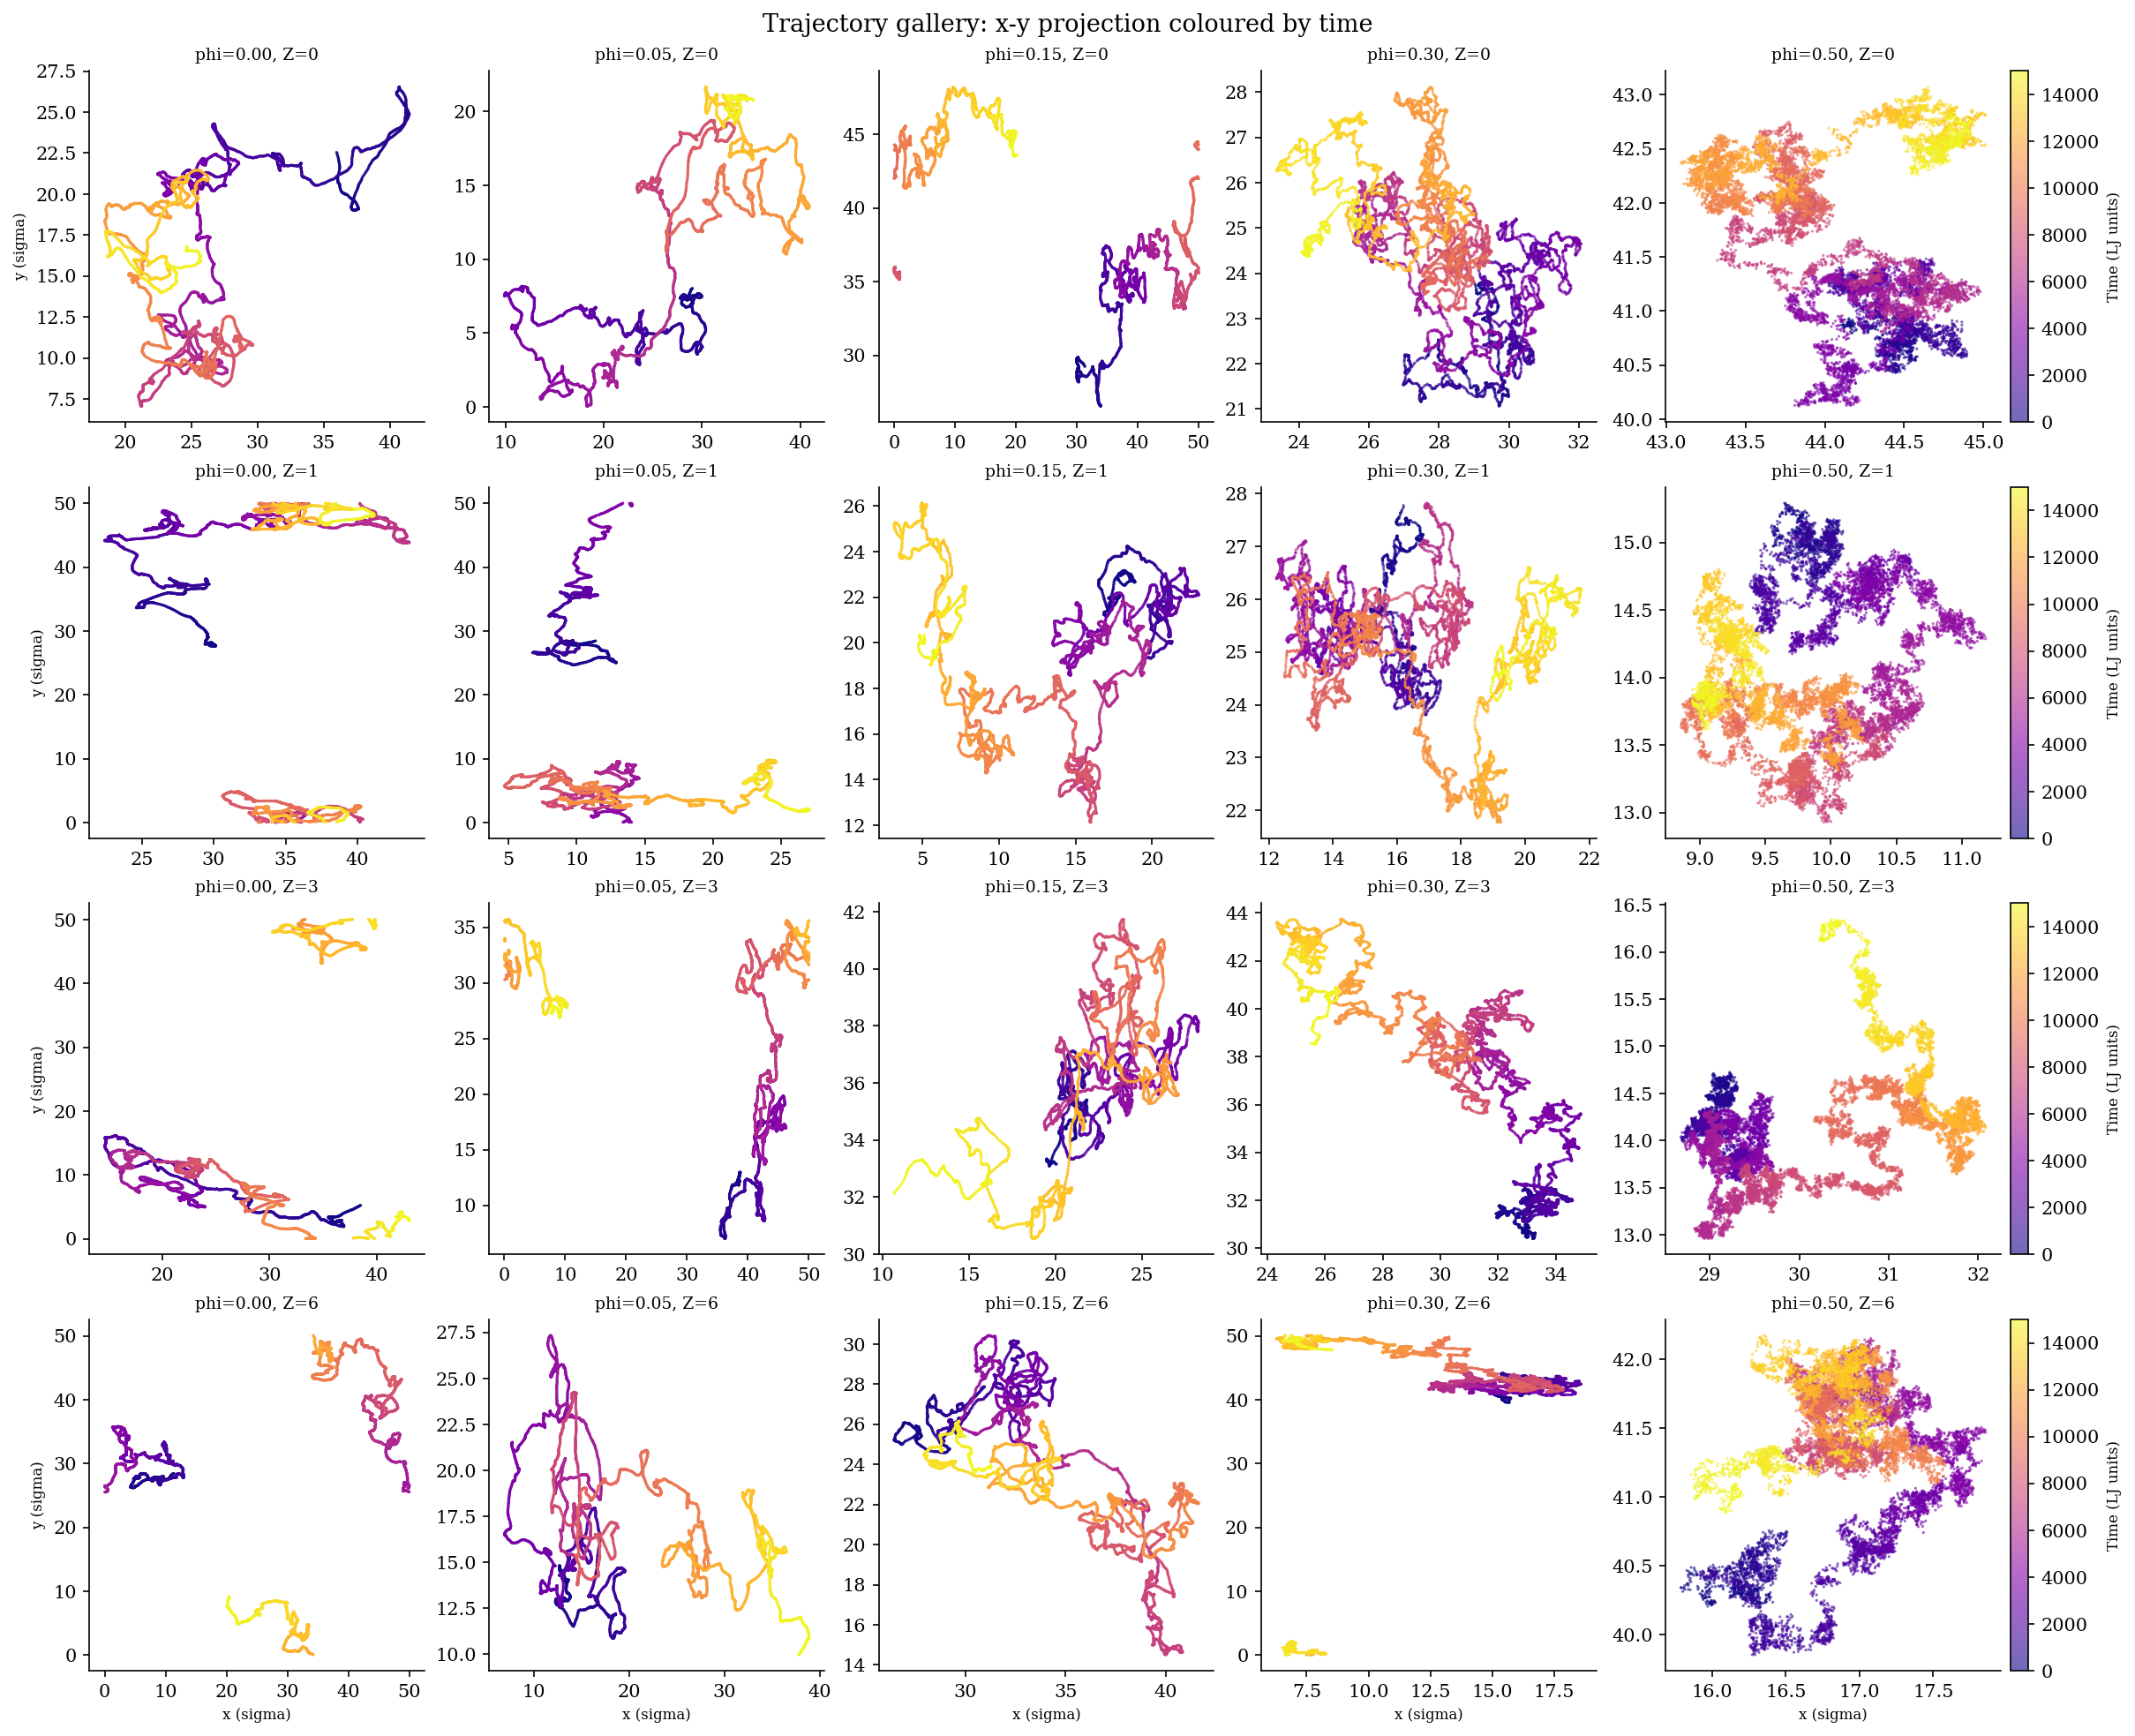

Saved: figures/01_trajectory_gallery.png


In [5]:
# Figure 01a: Trajectory gallery
# 4 rows (charge) x 5 columns (concentration)
# Each panel: 2D projection x vs y, coloured by time
fig, axes = plt.subplots(4, 5, figsize=(16, 13), constrained_layout=True)
cbar_ax   = None

for row_i, charge in enumerate(charges):
    for col_j, conc in enumerate(concs):
        ax  = axes[row_i, col_j]
        key = (conc, charge, 0)
        if key not in trajs:
            ax.set_visible(False)
            continue
        df = trajs[key]
        sc = ax.scatter(df['x'], df['y'],
                        c=df['t_index'], cmap='plasma',
                        s=0.3, alpha=0.6, rasterized=True)
        ax.set_title(f'phi={conc:.2f}, Z={charge:.0f}', fontsize=9)
        ax.set_xlabel('x (sigma)' if row_i == 3 else '', fontsize=8)
        ax.set_ylabel('y (sigma)' if col_j == 0 else '', fontsize=8)

        # Add colourbar on the rightmost column only
        if col_j == 4:
            cbar = fig.colorbar(sc, ax=ax, fraction=0.08, pad=0.02)
            cbar.set_label('Time (LJ units)', fontsize=8)

fig.suptitle('Trajectory gallery: x-y projection coloured by time', fontsize=13)
plt.savefig(f'{FIG_DIR}/01_trajectory_gallery.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/01_trajectory_gallery.png")


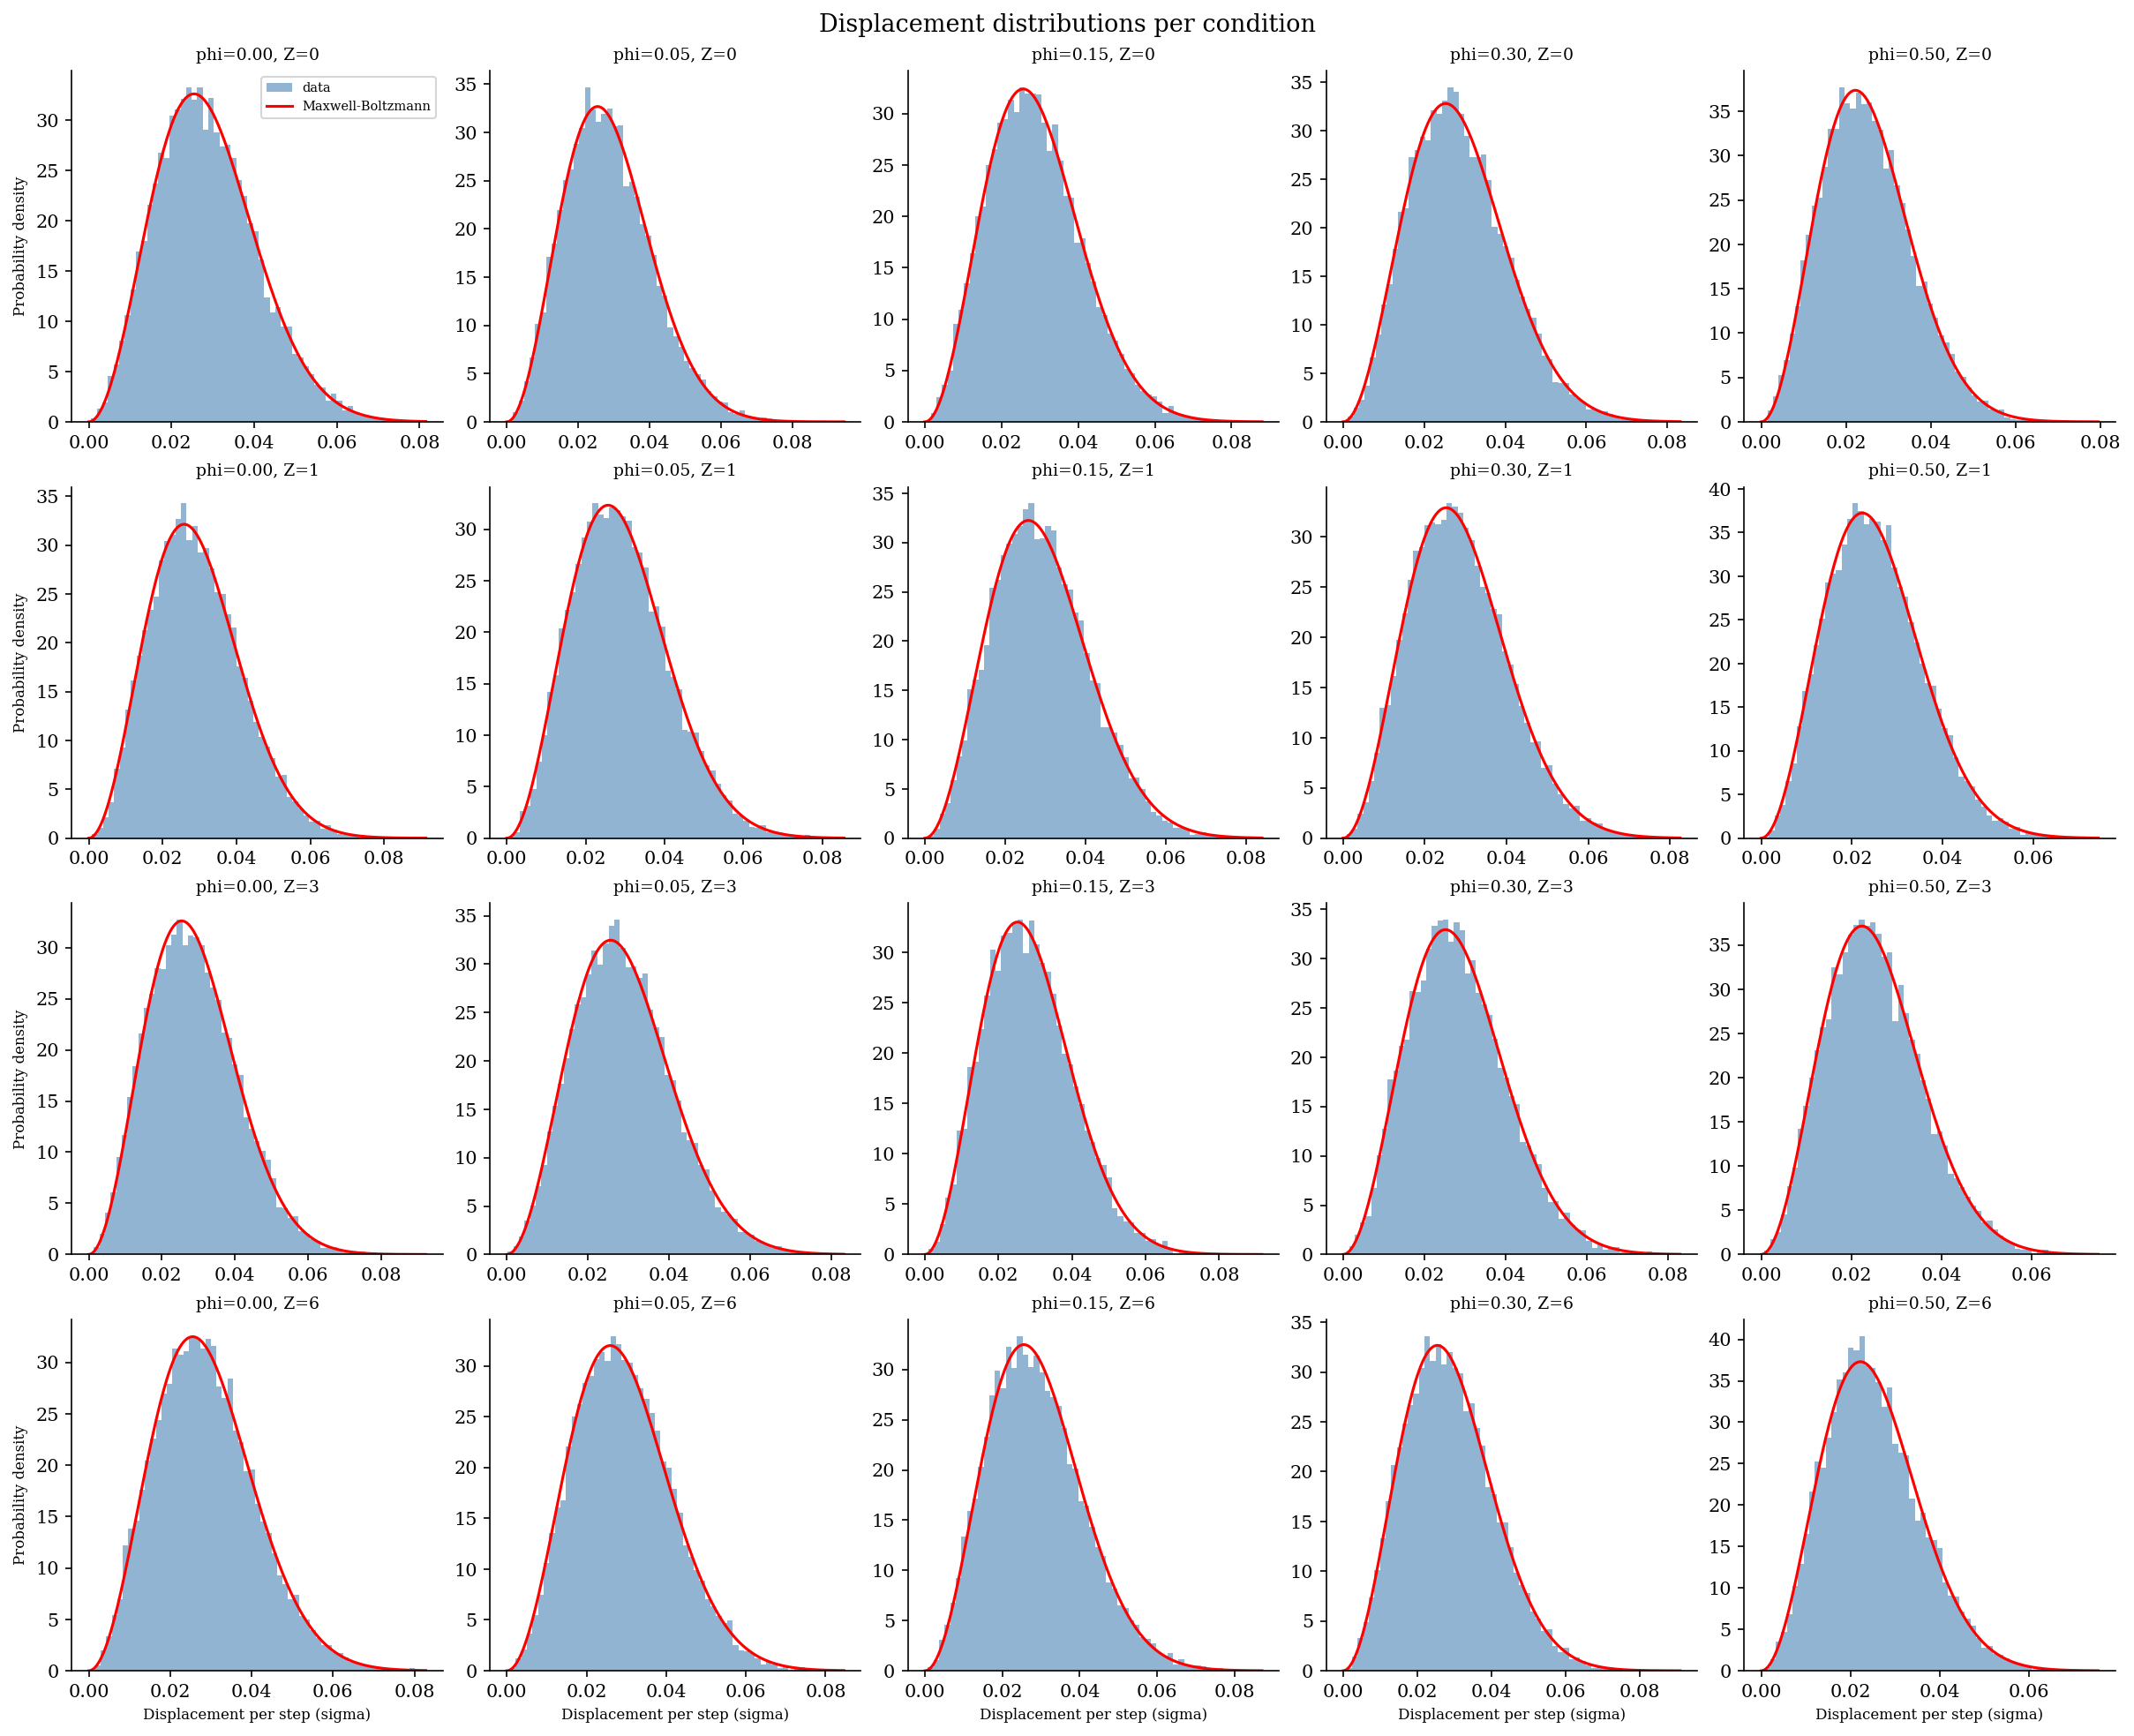

Saved: figures/01_displacement_distributions.png


In [6]:
# Figure 01b: Displacement distributions with Maxwell-Boltzmann overlay
# Maxwell-Boltzmann PDF for displacement magnitudes of a 3D Gaussian process:
#   p(r) = 4 pi r^2 * (1/(2 pi sigma^2))^(3/2) * exp(-r^2 / (2 sigma^2))
# where sigma^2 = mean(disp^2) / 3 (fitted from data).

from scipy.stats import maxwell

fig, axes = plt.subplots(4, 5, figsize=(16, 13), constrained_layout=True)

for row_i, charge in enumerate(charges):
    for col_j, conc in enumerate(concs):
        ax  = axes[row_i, col_j]
        key = (conc, charge, 0)
        if key not in trajs:
            ax.set_visible(False)
            continue
        df   = trajs[key]
        disp = df['displacement'].dropna().to_numpy()

        ax.hist(disp, bins=60, density=True, alpha=0.6,
                color='steelblue', label='data')

        # Fit Maxwell-Boltzmann: scale parameter a = sqrt(kT/m) * sqrt(dt)
        # Here we fit directly from the data second moment
        # Maxwell distribution has mean = 2a*sqrt(2/pi), scale = a
        # scipy.stats.maxwell.fit returns (loc, scale); loc fixed at 0
        _, scale = maxwell.fit(disp, floc=0)
        r_plot = np.linspace(0, disp.max(), 200)
        ax.plot(r_plot, maxwell.pdf(r_plot, scale=scale),
                'r-', lw=1.5, label='Maxwell-Boltzmann')

        ax.set_title(f'phi={conc:.2f}, Z={charge:.0f}', fontsize=9)
        ax.set_xlabel('Displacement per step (sigma)' if row_i == 3 else '', fontsize=8)
        ax.set_ylabel('Probability density' if col_j == 0 else '', fontsize=8)
        if row_i == 0 and col_j == 0:
            ax.legend(fontsize=7)

fig.suptitle('Displacement distributions per condition', fontsize=13)
plt.savefig(f'{FIG_DIR}/01_displacement_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/01_displacement_distributions.png")


In [7]:
# Summary statistics table
rows = []
for conc in concs:
    for charge in charges:
        disps_all = []
        for run_id in range(8):
            key = (conc, charge, run_id)
            if key not in trajs:
                continue
            d = trajs[key]['displacement'].dropna().to_numpy()
            disps_all.append(d)
        if not disps_all:
            continue
        all_disp = np.concatenate(disps_all)
        path_len = sum(d.sum() for d in disps_all) / 8  # mean total path length
        rows.append({
            'conc'        : conc,
            'charge'      : charge,
            'mean_disp'   : all_disp.mean(),
            'std_disp'    : all_disp.std(),
            'max_disp'    : all_disp.max(),
            'path_length' : path_len,
        })

summary_df = pd.DataFrame(rows).sort_values(['conc', 'charge'])
pd.set_option('display.float_format', '{:.4f}'.format)
print(summary_df.to_string(index=False))


  conc  charge  mean_disp  std_disp  max_disp  path_length
0.0000  0.0000     0.0289    0.0123    0.1087     433.7606
0.0000  1.0000     0.0287    0.0121    0.0977     430.6797
0.0000  3.0000     0.0287    0.0121    0.0923     429.7840
0.0000  6.0000     0.0288    0.0122    0.0897     432.0993
0.0500  0.0000     0.0289    0.0121    0.0961     433.4126
0.0500  1.0000     0.0290    0.0123    0.0956     435.3732
0.0500  3.0000     0.0287    0.0122    0.0926     430.8484
0.0500  6.0000     0.0291    0.0122    0.0983     435.8069
0.1500  0.0000     0.0290    0.0122    0.0956     435.4233
0.1500  1.0000     0.0290    0.0121    0.0912     434.3297
0.1500  3.0000     0.0288    0.0122    0.0917     431.5991
0.1500  6.0000     0.0289    0.0122    0.1011     433.6549
0.3000  0.0000     0.0285    0.0120    0.0942     426.7418
0.3000  1.0000     0.0285    0.0120    0.0928     426.9413
0.3000  3.0000     0.0285    0.0120    0.0976     426.8725
0.3000  6.0000     0.0285    0.0120    0.0908     426.77